In [20]:
# =============================================================================
# Zelle 01 – Setup & Daten laden (Modelltraining Modell B)
# =============================================================================
import sys
sys.path.append('../src')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE
from preprocessing import load_dataset_b, FEATURE_SETS_B, WandstaerkeDNResidualizer, baue_preprocessing_pipeline_b, X_B_MERKMALE_ENCODED, Y_B_MERKMALE

SEED = 42
apply_store44_style()

df_b = load_dataset_b("../data/processed/model_b_preprocessed.csv")

print(f"Datensatz: {df_b.shape}")
print(f"X_B (encoded, {len(X_B_MERKMALE_ENCODED)}): {X_B_MERKMALE_ENCODED}")
print(f"Y_B ({len(Y_B_MERKMALE)}): {Y_B_MERKMALE}")
print(f"Feature-Set-Kandidaten: {list(FEATURE_SETS_B.keys())}")

Datensatz: (2000, 14)
X_B (encoded, 7): ['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung', 'wandtyp_einwandig']
Y_B (6): ['schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'vakuumniveau', 'innenluftdruck', 'kuehlwassertemperatur']
Feature-Set-Kandidaten: ['original', 'nur_dn', 'nur_wandstaerke', 'residualisiert']


In [21]:
# =============================================================================
# Zelle 02 – Train/Test-Split (einmalig fixiert, fuer alle Kombinationen)
# =============================================================================
# Analog Modell A: ein einziger Split, konsistent fuer alle Feature-Sets
# und Modellkombinationen verwendet. Kein Stratify noetig (keine
# Klassifikation, alle Y_B kontinuierlich).
# =============================================================================
from sklearn.model_selection import train_test_split, KFold

train_idx, test_idx = train_test_split(df_b.index, test_size=0.2, random_state=SEED)

print(f"Train: {len(train_idx)} Zeilen, Test: {len(test_idx)} Zeilen")

# --- Aeussere 5-Fold-CV, konsistent fuer alle Kombinationen ---
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_splits = list(kf.split(train_idx))
fold_splits_idx = [(train_idx[tr_pos], train_idx[val_pos]) for tr_pos, val_pos in fold_splits]

print(f"Folds: {len(fold_splits_idx)}")
print(f"Beispiel Fold 0: Train={len(fold_splits_idx[0][0])}, Val={len(fold_splits_idx[0][1])}")

Train: 1600 Zeilen, Test: 400 Zeilen
Folds: 5
Beispiel Fold 0: Train=1280, Val=320


In [22]:
# =============================================================================
# Zelle 02b – Verteilungspruefung: Y_B in Train/Test/Folds vergleichbar?
# =============================================================================
# Bei kontinuierlichen Zielgroessen gibt es keine automatische Stratifizierung
# (im Gegensatz zu Klassifikation) - muss explizit geprueft werden, ob
# Zufalls-Split zu verzerrten Teilmengen fuehrt.
# =============================================================================

print("=== Train vs. Test: Mittelwert und Std je Y_B-Groesse ===")
vergleich_train_test = []
for y_col in Y_B_MERKMALE:
    train_werte = df_b.loc[train_idx, y_col]
    test_werte = df_b.loc[test_idx, y_col]
    vergleich_train_test.append({
        "y_merkmal": y_col,
        "train_mean": round(train_werte.mean(), 2), "test_mean": round(test_werte.mean(), 2),
        "train_std": round(train_werte.std(), 2), "test_std": round(test_werte.std(), 2),
        "differenz_mean_prozent": round(abs(train_werte.mean()-test_werte.mean())/train_werte.mean()*100, 2),
    })
vergleich_df_split = pd.DataFrame(vergleich_train_test)
print(vergleich_df_split.to_string(index=False))

print("\n=== Verteilung je Fold (Mittelwert), alle 5 Folds ===")
fold_vergleich = []
for fold_num, (tr_idx, val_idx) in enumerate(fold_splits_idx):
    for y_col in Y_B_MERKMALE:
        fold_vergleich.append({
            "fold": fold_num, "y_merkmal": y_col,
            "val_mean": round(df_b.loc[val_idx, y_col].mean(), 2),
            "val_std": round(df_b.loc[val_idx, y_col].std(), 2),
        })
fold_df = pd.DataFrame(fold_vergleich)
fold_pivot = fold_df.pivot(index="y_merkmal", columns="fold", values="val_mean")
print(fold_pivot.to_string())

fold_pivot.to_csv("../reports/tables/11_fold_verteilung_check_model_b.csv")
vergleich_df_split.to_csv("../reports/tables/11_train_test_verteilung_check_model_b.csv", index=False)

=== Train vs. Test: Mittelwert und Std je Y_B-Groesse ===
            y_merkmal  train_mean  test_mean  train_std  test_std  differenz_mean_prozent
    schneckendrehzahl       44.08      44.33       7.32      7.54                    0.57
      massetemperatur      204.33     204.30       5.80      5.80                    0.01
          duesenspalt        2.26       2.26       0.64      0.71                    0.19
         vakuumniveau       97.81      98.53      17.68     17.34                    0.74
       innenluftdruck       80.00      79.40      16.79     18.08                    0.75
kuehlwassertemperatur       19.05      19.11       2.89      2.99                    0.32

=== Verteilung je Fold (Mittelwert), alle 5 Folds ===
fold                        0       1       2       3       4
y_merkmal                                                    
duesenspalt              2.20    2.26    2.19    2.35    2.28
innenluftdruck          79.92   79.54   81.85   79.05   79.63
kuehlwass

In [23]:
# =============================================================================
# Zelle 03 – Modell-Registry: 8 Modelltypen fuer Multi-Output-Regression
# =============================================================================
# Konservative Standard-Hyperparameter (kein Tuning in diesem AP, analog
# Modell A AP 3.4). random_state=SEED durchgaengig.
# =============================================================================
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# --- Basis-Modelle (werden je nach Bedarf pur oder mit MultiOutputRegressor-Wrapper verwendet) ---
MODELLE_B = {
    "Ridge": {"modell": Ridge(random_state=SEED), "nativ_multioutput": True},
    "RandomForest": {"modell": RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=SEED), "nativ_multioutput": True},
    "kNN": {"modell": KNeighborsRegressor(n_neighbors=5), "nativ_multioutput": True},
    "MLP": {"modell": MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, early_stopping=True, random_state=SEED), "nativ_multioutput": True},
    "SVR": {"modell": SVR(C=1.0, kernel="rbf"), "nativ_multioutput": False},
    "HistGradientBoosting": {"modell": HistGradientBoostingRegressor(max_iter=50, max_depth=3, max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0, random_state=SEED), "nativ_multioutput": False},
    "XGBoost": {"modell": XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, random_state=SEED), "nativ_multioutput": False},
    "LightGBM": {"modell": LGBMRegressor(n_estimators=50, num_leaves=7, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_samples=30, random_state=SEED, verbose=-1), "nativ_multioutput": False},
}

print("Modell-Registry (8 Typen):")
for name, konfig in MODELLE_B.items():
    print(f"  {name:22s} nativ_multioutput={konfig['nativ_multioutput']}")

Modell-Registry (8 Typen):
  Ridge                  nativ_multioutput=True
  RandomForest           nativ_multioutput=True
  kNN                    nativ_multioutput=True
  MLP                    nativ_multioutput=True
  SVR                    nativ_multioutput=False
  HistGradientBoosting   nativ_multioutput=False
  XGBoost                nativ_multioutput=False
  LightGBM               nativ_multioutput=False


In [24]:
# =============================================================================
# Zelle 04 – Metrik-Funktion: vollstaendiges Set (bestaetigt durch Nutzer)
# =============================================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

def berechne_metriken_b(y_true, y_pred, y_true_std):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    rmse_normiert = rmse / y_true_std if y_true_std > 0 else np.nan
    mae_normiert = mae / y_true_std if y_true_std > 0 else np.nan
    return {
        "mae": mae, "rmse": rmse, "r2": r2, "median_ae": medae,
        "rmse_normiert": rmse_normiert, "mae_normiert": mae_normiert,
    }

print("Metrik-Funktion definiert: mae, rmse, r2, median_ae, rmse_normiert, mae_normiert")
print("Train-CV-Gap, Fold-Std, Fit-Zeit, Predict-Zeit: in Ablationsschleife (Zelle 05)")
print("Prediction Interval Coverage: separater Zusatzschritt nur fuer RandomForest/Ridge/kNN (spaeter)")

Metrik-Funktion definiert: mae, rmse, r2, median_ae, rmse_normiert, mae_normiert
Train-CV-Gap, Fold-Std, Fit-Zeit, Predict-Zeit: in Ablationsschleife (Zelle 05)
Prediction Interval Coverage: separater Zusatzschritt nur fuer RandomForest/Ridge/kNN (spaeter)


In [25]:
# =============================================================================
# Zelle 05 – Ablationsschleife: 4 Feature-Sets x 8 Modelle x Struktur-Varianten
# =============================================================================
# Try/Except + Zwischenspeicherung je Kombination (bewaehrtes Robustheits-
# muster aus Modell A). Fuer nativ-multioutput-faehige Modelle werden BEIDE
# Strukturvarianten (Multi-Output vs. 6 Einzelmodelle) getestet.
# =============================================================================
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")

OUTPUT_CSV_B = "../reports/tables/11_ablation_results_model_b.csv"

y_std_je_merkmal = {y: df_b.loc[train_idx, y].std() for y in Y_B_MERKMALE}

kombinationen = []
for modell_name, konfig in MODELLE_B.items():
    for struktur in (["multioutput", "einzeln"] if konfig["nativ_multioutput"] else ["einzeln"]):
        for fs_name in FEATURE_SETS_B:
            kombinationen.append((modell_name, struktur, fs_name))

ergebnisse_b = []
start_gesamt = time.time()

for kombi_idx, (modell_name, struktur, fs_name) in enumerate(kombinationen):
    eintrag = {"modell": modell_name, "struktur": struktur, "feature_set": fs_name, "status": "ok"}
    fold_metriken_je_y = {y: [] for y in Y_B_MERKMALE}
    fold_metriken_train_je_y = {y: [] for y in Y_B_MERKMALE}
    fold_fit_zeiten, fold_predict_zeiten = [], []

    try:
        for tr_idx, val_idx in fold_splits_idx:
            prep = baue_preprocessing_pipeline_b(fs_name)
            X_tr = prep.fit_transform(df_b.loc[tr_idx])
            X_val = prep.transform(df_b.loc[val_idx])
            y_tr = df_b.loc[tr_idx, Y_B_MERKMALE]
            y_val = df_b.loc[val_idx, Y_B_MERKMALE]

            t0 = time.time()
            if struktur == "multioutput":
                modell = clone(MODELLE_B[modell_name]["modell"])
                modell.fit(X_tr, y_tr)
                fit_zeit = time.time() - t0
                t1 = time.time()
                y_pred_val = pd.DataFrame(modell.predict(X_val), columns=Y_B_MERKMALE, index=val_idx)
                y_pred_train = pd.DataFrame(modell.predict(X_tr), columns=Y_B_MERKMALE, index=tr_idx)
                predict_zeit = time.time() - t1
            else:
                y_pred_val = pd.DataFrame(index=val_idx, columns=Y_B_MERKMALE, dtype=float)
                y_pred_train = pd.DataFrame(index=tr_idx, columns=Y_B_MERKMALE, dtype=float)
                predict_zeit_summe = 0
                for y_col in Y_B_MERKMALE:
                    modell_einzeln = clone(MODELLE_B[modell_name]["modell"])
                    modell_einzeln.fit(X_tr, y_tr[y_col])
                    t1 = time.time()
                    y_pred_val[y_col] = modell_einzeln.predict(X_val)
                    y_pred_train[y_col] = modell_einzeln.predict(X_tr)
                    predict_zeit_summe += time.time() - t1
                fit_zeit = time.time() - t0 - predict_zeit_summe
                predict_zeit = predict_zeit_summe

            fold_fit_zeiten.append(fit_zeit)
            fold_predict_zeiten.append(predict_zeit)

            for y_col in Y_B_MERKMALE:
                m_val = berechne_metriken_b(y_val[y_col], y_pred_val[y_col], y_std_je_merkmal[y_col])
                m_train = berechne_metriken_b(y_tr[y_col], y_pred_train[y_col], y_std_je_merkmal[y_col])
                fold_metriken_je_y[y_col].append(m_val)
                fold_metriken_train_je_y[y_col].append(m_train)

        for y_col in Y_B_MERKMALE:
            for metrik_key in ["mae", "rmse", "r2", "median_ae", "rmse_normiert", "mae_normiert"]:
                werte_val = [fm[metrik_key] for fm in fold_metriken_je_y[y_col]]
                werte_train = [fm[metrik_key] for fm in fold_metriken_train_je_y[y_col]]
                eintrag[f"{y_col}_{metrik_key}_mean"] = np.nanmean(werte_val)
                eintrag[f"{y_col}_{metrik_key}_std"] = np.nanstd(werte_val)
                eintrag[f"{y_col}_{metrik_key}_gap"] = np.nanmean(werte_train) - np.nanmean(werte_val)

        eintrag["fit_zeit_sekunden_mean"] = np.mean(fold_fit_zeiten)
        eintrag["predict_zeit_sekunden_mean"] = np.mean(fold_predict_zeiten)
        eintrag["r2_durchschnitt_alle_y"] = np.mean([eintrag[f"{y}_r2_mean"] for y in Y_B_MERKMALE])

    except Exception as e:
        eintrag["status"] = "fehlgeschlagen"
        eintrag["fehler"] = f"{type(e).__name__}: {str(e)[:300]}"

    ergebnisse_b.append(eintrag)
    pd.DataFrame(ergebnisse_b).to_csv(OUTPUT_CSV_B, index=False)
    print(f"[{kombi_idx+1}/{len(kombinationen)}] {modell_name:22s} {struktur:11s} {fs_name:16s} -> {eintrag['status']}")

print(f"\nGesamtzeit: {time.time()-start_gesamt:.1f}s")
ergebnisse_b_df = pd.DataFrame(ergebnisse_b)
print(f"Erfolgreich: {(ergebnisse_b_df['status']=='ok').sum()} / {len(ergebnisse_b_df)}")

[1/48] Ridge                  multioutput original         -> ok
[2/48] Ridge                  multioutput nur_dn           -> ok
[3/48] Ridge                  multioutput nur_wandstaerke  -> ok
[4/48] Ridge                  multioutput residualisiert   -> ok
[5/48] Ridge                  einzeln     original         -> ok
[6/48] Ridge                  einzeln     nur_dn           -> ok
[7/48] Ridge                  einzeln     nur_wandstaerke  -> ok
[8/48] Ridge                  einzeln     residualisiert   -> ok
[9/48] RandomForest           multioutput original         -> ok
[10/48] RandomForest           multioutput nur_dn           -> ok
[11/48] RandomForest           multioutput nur_wandstaerke  -> ok
[12/48] RandomForest           multioutput residualisiert   -> ok
[13/48] RandomForest           einzeln     original         -> ok
[14/48] RandomForest           einzeln     nur_dn           -> ok
[15/48] RandomForest           einzeln     nur_wandstaerke  -> ok
[16/48] RandomFores

In [26]:
# =============================================================================
# Zelle 06 – Frage 1: Multi-Output vs. Einzelmodelle (datengetrieben)
# =============================================================================
# Nur bei Ridge, RandomForest, kNN, MLP moeglich (einzige Modelle mit
# echter Strukturwahl) - direkter Vergleich derselben Modell/Feature-Set-
# Kombination unter beiden Strukturvarianten.
# =============================================================================
ergebnisse_b_df = pd.read_csv("../reports/tables/11_ablation_results_model_b.csv")

nativ_modelle = ["Ridge", "RandomForest", "kNN", "MLP"]

vergleich_struktur = []
for modell_name in nativ_modelle:
    for fs_name in FEATURE_SETS_B:
        multi = ergebnisse_b_df[(ergebnisse_b_df["modell"]==modell_name) & (ergebnisse_b_df["struktur"]=="multioutput") & (ergebnisse_b_df["feature_set"]==fs_name)]
        einzeln = ergebnisse_b_df[(ergebnisse_b_df["modell"]==modell_name) & (ergebnisse_b_df["struktur"]=="einzeln") & (ergebnisse_b_df["feature_set"]==fs_name)]
        if len(multi)==0 or len(einzeln)==0:
            continue
        vergleich_struktur.append({
            "modell": modell_name, "feature_set": fs_name,
            "r2_multioutput": round(multi.iloc[0]["r2_durchschnitt_alle_y"], 4),
            "r2_einzeln": round(einzeln.iloc[0]["r2_durchschnitt_alle_y"], 4),
            "differenz": round(multi.iloc[0]["r2_durchschnitt_alle_y"] - einzeln.iloc[0]["r2_durchschnitt_alle_y"], 4),
            "fit_zeit_multioutput": round(multi.iloc[0]["fit_zeit_sekunden_mean"], 4),
            "fit_zeit_einzeln": round(einzeln.iloc[0]["fit_zeit_sekunden_mean"], 4),
        })

vergleich_struktur_df = pd.DataFrame(vergleich_struktur)
print(vergleich_struktur_df.to_string(index=False))
vergleich_struktur_df.to_csv("../reports/tables/11_multioutput_vs_einzeln_vergleich.csv", index=False)

print(f"\n=== Zusammenfassung ueber alle Feature-Sets, je Modell ===")
print(vergleich_struktur_df.groupby("modell")["differenz"].agg(["mean", "std"]).round(4))

      modell     feature_set  r2_multioutput  r2_einzeln  differenz  fit_zeit_multioutput  fit_zeit_einzeln
       Ridge        original          0.5674      0.5674     0.0000                0.0045            0.0097
       Ridge          nur_dn          0.5533      0.5533     0.0000                0.0000            0.0108
       Ridge nur_wandstaerke          0.5479      0.5479     0.0000                0.0036            0.0067
       Ridge  residualisiert          0.5674      0.5674    -0.0000                0.0028            0.0090
RandomForest        original          0.5224      0.5404    -0.0180                0.7176            3.4434
RandomForest          nur_dn          0.5120      0.5223    -0.0103                0.6732            2.9032
RandomForest nur_wandstaerke          0.5109      0.5205    -0.0097                0.5760            2.9686
RandomForest  residualisiert          0.5156      0.5371    -0.0216                0.6187            3.3311
         kNN        original

In [27]:
# =============================================================================
# Zelle 07 – Frage 2: Feature-Set-Vergleich (alle 8 Modelle, beste Struktur je Modell)
# =============================================================================
# Fuer jedes Modell wird die JEWEILS BESTE Struktur-Variante herangezogen
# (aus Zelle 06 Erkenntnis: Ridge/kNN egal, RandomForest -> einzeln leicht
# besser, MLP -> multioutput klar besser). Fokus hier: welches Feature-Set
# ist ueber alle Modelle hinweg am staerksten?
# =============================================================================

beste_struktur_je_modell = {
    "Ridge": "multioutput",  # gleich, aber schneller
    "RandomForest": "einzeln",  # leicht besser
    "kNN": "multioutput",  # gleich, aber schneller
    "MLP": "multioutput",  # klar besser
    "SVR": "einzeln", "HistGradientBoosting": "einzeln", "XGBoost": "einzeln", "LightGBM": "einzeln",
}

feature_set_vergleich = []
for modell_name, struktur in beste_struktur_je_modell.items():
    for fs_name in FEATURE_SETS_B:
        zeile = ergebnisse_b_df[(ergebnisse_b_df["modell"]==modell_name) & (ergebnisse_b_df["struktur"]==struktur) & (ergebnisse_b_df["feature_set"]==fs_name)]
        if len(zeile) == 0:
            continue
        feature_set_vergleich.append({
            "modell": modell_name, "feature_set": fs_name,
            "r2_durchschnitt": round(zeile.iloc[0]["r2_durchschnitt_alle_y"], 4),
        })

fs_vergleich_df = pd.DataFrame(feature_set_vergleich)
pivot_fs = fs_vergleich_df.pivot(index="modell", columns="feature_set", values="r2_durchschnitt")
pivot_fs["bestes_feature_set"] = pivot_fs.idxmax(axis=1)
print(pivot_fs.to_string())

print(f"\n=== Durchschnitt je Feature-Set (ueber alle 8 Modelle) ===")
print(fs_vergleich_df.groupby("feature_set")["r2_durchschnitt"].agg(["mean", "std"]).sort_values("mean", ascending=False).round(4))

pivot_fs.to_csv("../reports/tables/11_feature_set_vergleich_model_b.csv")

feature_set           nur_dn  nur_wandstaerke  original  residualisiert bestes_feature_set
modell                                                                                    
HistGradientBoosting  0.5351           0.5329    0.5490          0.5464           original
LightGBM              0.5329           0.5341    0.5493          0.5469           original
MLP                   0.3957           0.3918    0.4097          0.3616           original
RandomForest          0.5223           0.5205    0.5404          0.5371           original
Ridge                 0.5533           0.5479    0.5674          0.5674           original
SVR                   0.5064           0.5047    0.5261          0.5174           original
XGBoost               0.5318           0.5295    0.5515          0.5456           original
kNN                   0.4202           0.4177    0.4461          0.4105           original

=== Durchschnitt je Feature-Set (ueber alle 8 Modelle) ===
                   mean     st

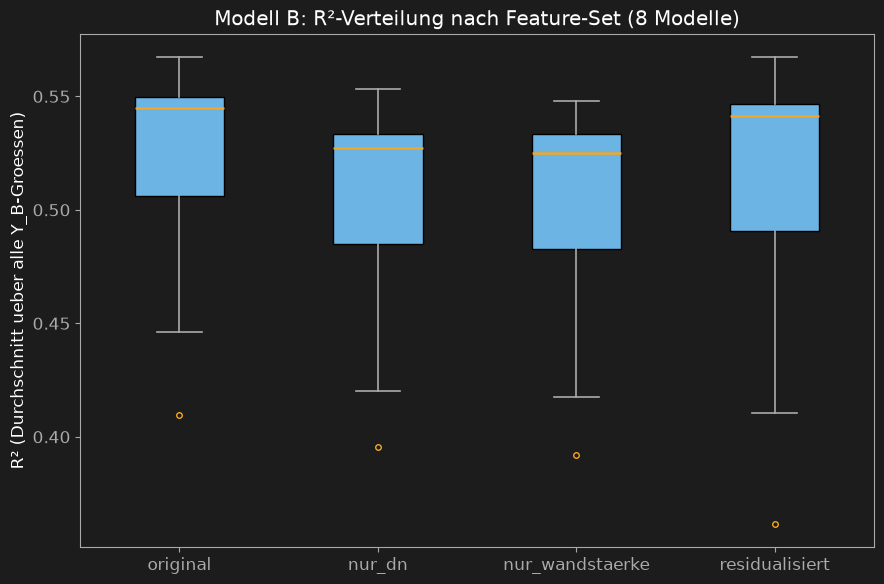

In [34]:
# =============================================================================
# Zelle 07b – Grafik: Boxplot R2-Verteilung ueber Feature-Sets (alle 8 Modelle)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))

daten_je_fs = [fs_vergleich_df[fs_vergleich_df["feature_set"]==fs]["r2_durchschnitt"].values for fs in FEATURE_SETS_B]
bp = ax.boxplot(daten_je_fs, tick_labels=list(FEATURE_SETS_B.keys()), patch_artist=True, **BOXPLOT_STYLE)
for box in bp["boxes"]:
    box.set_facecolor(COLOR_BLUE)

ax.set_ylabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_title("Modell B: R²-Verteilung nach Feature-Set (8 Modelle)")
plt.tight_layout()
save_figure(fig, "../reports/figures/11_boxplot_feature_sets_model_b.png")
plt.show()

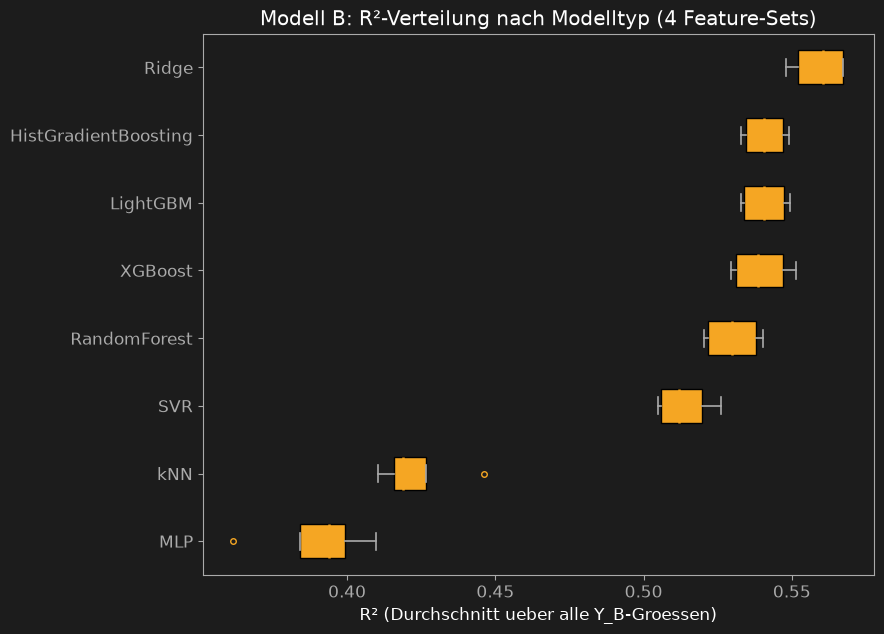

In [35]:
# =============================================================================
# Zelle 07c – Grafik: Boxplot R2-Verteilung ueber Modelltypen (alle 4 Feature-Sets)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6.5))

modelle_sortiert = fs_vergleich_df.groupby("modell")["r2_durchschnitt"].median().sort_values(ascending=True).index.tolist()
daten_je_modell = [fs_vergleich_df[fs_vergleich_df["modell"]==m]["r2_durchschnitt"].values for m in modelle_sortiert]

bp = ax.boxplot(daten_je_modell, tick_labels=modelle_sortiert, patch_artist=True, vert=False, **BOXPLOT_STYLE)
for box in bp["boxes"]:
    box.set_facecolor(COLOR_GOLD)

ax.set_xlabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_title("Modell B: R²-Verteilung nach Modelltyp (4 Feature-Sets)")
plt.tight_layout()
save_figure(fig, "../reports/figures/11_boxplot_modelltypen_model_b.png")
plt.show()

In [28]:
# =============================================================================
# Zelle 08 – Gesamtvergleich: Genauigkeit, Robustheit (Gap), Rechenzeit
# =============================================================================
# Feature-Set fixiert auf "original" (datengetriebenes Ergebnis aus Zelle 07).
# Struktur je Modell wie in Zelle 07 (beste_struktur_je_modell).
# =============================================================================

gesamtvergleich = []
for modell_name, struktur in beste_struktur_je_modell.items():
    zeile = ergebnisse_b_df[(ergebnisse_b_df["modell"]==modell_name) & (ergebnisse_b_df["struktur"]==struktur) & (ergebnisse_b_df["feature_set"]=="original")]
    if len(zeile) == 0:
        continue
    row = zeile.iloc[0]

    # Durchschnittlicher Gap ueber alle 6 Y_B-Groessen (R2-Gap: Train-R2 minus Val-R2)
    gap_werte = [row[f"{y}_r2_gap"] for y in Y_B_MERKMALE]
    durchschnitt_gap = np.mean(gap_werte)

    gesamtvergleich.append({
        "modell": modell_name, "struktur": struktur,
        "r2_durchschnitt": round(row["r2_durchschnitt_alle_y"], 4),
        "r2_gap_durchschnitt": round(durchschnitt_gap, 4),
        "fit_zeit_sek": round(row["fit_zeit_sekunden_mean"], 4),
        "predict_zeit_sek": round(row["predict_zeit_sekunden_mean"], 5),
    })

gesamt_df = pd.DataFrame(gesamtvergleich).sort_values("r2_durchschnitt", ascending=False)
print(gesamt_df.to_string(index=False))
gesamt_df.to_csv("../reports/tables/11_gesamtvergleich_model_b.csv", index=False)

              modell    struktur  r2_durchschnitt  r2_gap_durchschnitt  fit_zeit_sek  predict_zeit_sek
               Ridge multioutput           0.5674               0.0063        0.0045           0.00056
             XGBoost     einzeln           0.5515               0.0930        0.3673           0.03302
            LightGBM     einzeln           0.5493               0.0835        0.1687           0.04231
HistGradientBoosting     einzeln           0.5490               0.0919        1.7569           0.03925
        RandomForest     einzeln           0.5404               0.2350        3.4434           0.29250
                 SVR     einzeln           0.5261               0.0396        0.7975           1.87112
                 kNN multioutput           0.4461               0.1860        0.0037           0.01106
                 MLP multioutput           0.4097               0.0410        2.2124           0.00582


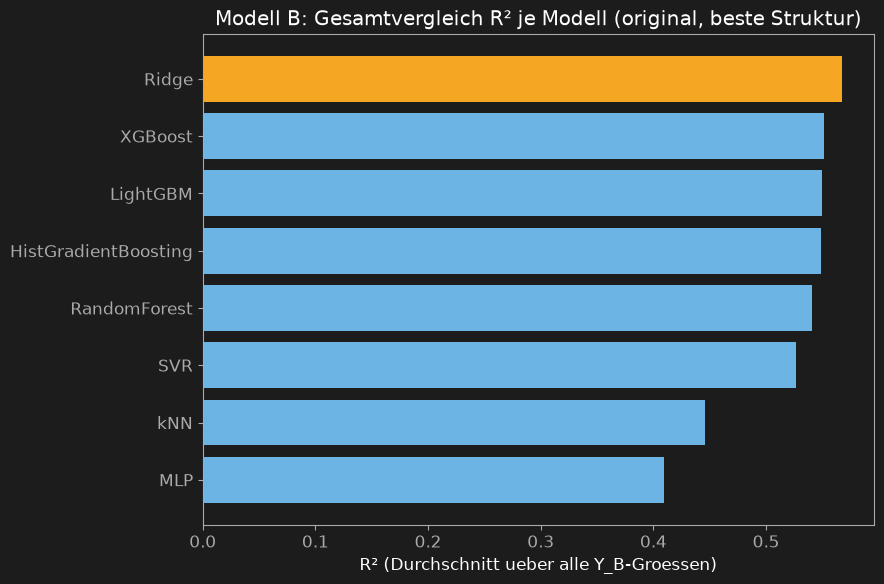

In [36]:
# =============================================================================
# Zelle 08b – Grafik: R² je Modell (Balkendiagramm, beste Struktur je Modell)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))

gesamt_sortiert = gesamt_df.sort_values("r2_durchschnitt", ascending=True)
farben = [COLOR_GOLD if m == gesamt_sortiert.iloc[-1]["modell"] else COLOR_BLUE for m in gesamt_sortiert["modell"]]

ax.barh(gesamt_sortiert["modell"], gesamt_sortiert["r2_durchschnitt"], color=farben)
ax.set_xlabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_title("Modell B: Gesamtvergleich R² je Modell (original, beste Struktur)")
plt.tight_layout()
save_figure(fig, "../reports/figures/11_r2_je_modell_model_b.png")
plt.show()

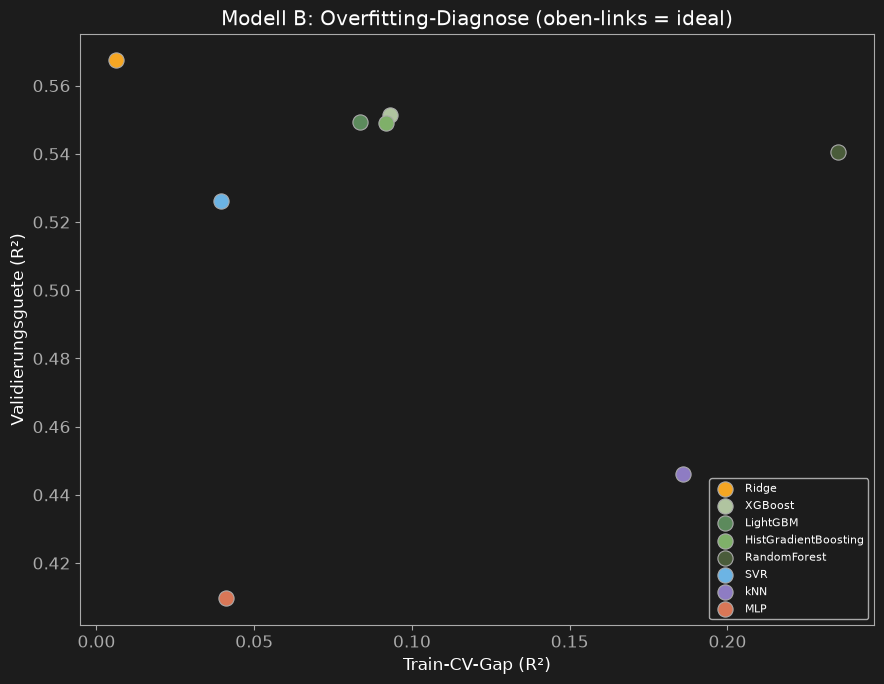

In [37]:
# =============================================================================
# Zelle 08c – Grafik: Train-CV-Gap vs. R² (Overfitting-Diagnose)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 7))

modell_farben_b = {
    "Ridge": "#F5A623", "RandomForest": "#4A5C3A", "kNN": "#8E7CC3", "MLP": "#D97757",
    "SVR": "#6CB4E4", "HistGradientBoosting": "#7FB069", "XGBoost": "#B0C4A0", "LightGBM": "#5C8A5C",
}

for _, row in gesamt_df.iterrows():
    ax.scatter(row["r2_gap_durchschnitt"], row["r2_durchschnitt"], color=modell_farben_b.get(row["modell"], COLOR_TEXT_MUTED),
               s=120, edgecolors=COLOR_TEXT_MUTED, linewidths=0.8, label=row["modell"])

ax.set_xlabel("Train-CV-Gap (R²)")
ax.set_ylabel("Validierungsguete (R²)")
ax.set_title("Modell B: Overfitting-Diagnose (oben-links = ideal)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
save_figure(fig, "../reports/figures/11_overfitting_diagnose_model_b.png")
plt.show()

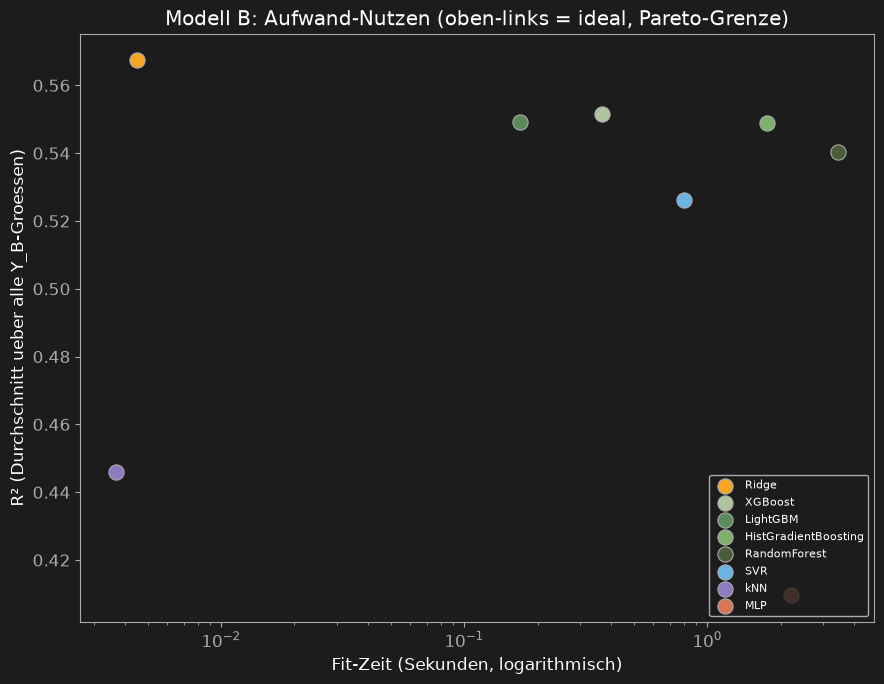

In [38]:
# =============================================================================
# Zelle 08d – Grafik: Fit-Zeit vs. R² (Aufwand-Nutzen-Vergleich)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 7))

for _, row in gesamt_df.iterrows():
    ax.scatter(row["fit_zeit_sek"], row["r2_durchschnitt"], color=modell_farben_b.get(row["modell"], COLOR_TEXT_MUTED),
               s=120, edgecolors=COLOR_TEXT_MUTED, linewidths=0.8, label=row["modell"])

ax.set_xlabel("Fit-Zeit (Sekunden, logarithmisch)")
ax.set_ylabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_xscale("log")
ax.set_title("Modell B: Aufwand-Nutzen (oben-links = ideal, Pareto-Grenze)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
save_figure(fig, "../reports/figures/11_aufwand_nutzen_model_b.png")
plt.show()

In [29]:
# =============================================================================
# Zelle 09 – R² pro einzelner Y_B-Groesse (Aufschluesselung des Durchschnitts)
# =============================================================================
aufschluesselung = []
for modell_name, struktur in beste_struktur_je_modell.items():
    zeile = ergebnisse_b_df[(ergebnisse_b_df["modell"]==modell_name) & (ergebnisse_b_df["struktur"]==struktur) & (ergebnisse_b_df["feature_set"]=="original")]
    if len(zeile) == 0:
        continue
    row = zeile.iloc[0]
    eintrag = {"modell": modell_name}
    for y_col in Y_B_MERKMALE:
        eintrag[y_col] = round(row[f"{y_col}_r2_mean"], 3)
    aufschluesselung.append(eintrag)

aufschluesselung_df = pd.DataFrame(aufschluesselung).set_index("modell")
print(aufschluesselung_df.to_string())

print(f"\n=== Bestes R2 je Y_B-Groesse (ueber alle Modelle) ===")
print(aufschluesselung_df.max().sort_values(ascending=False))

aufschluesselung_df.to_csv("../reports/tables/11_r2_je_y_b_groesse.csv")

                      schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
modell                                                                                                                    
Ridge                             0.830            0.475        0.950         0.367           0.517                  0.266
RandomForest                      0.811            0.446        0.944         0.337           0.486                  0.219
kNN                               0.714            0.339        0.903         0.233           0.389                  0.099
MLP                               0.784           -0.327        0.935         0.353           0.484                  0.229
SVR                               0.767            0.433        0.939         0.340           0.452                  0.225
HistGradientBoosting              0.808            0.455        0.947         0.353           0.497                  0.234
XGBoost         

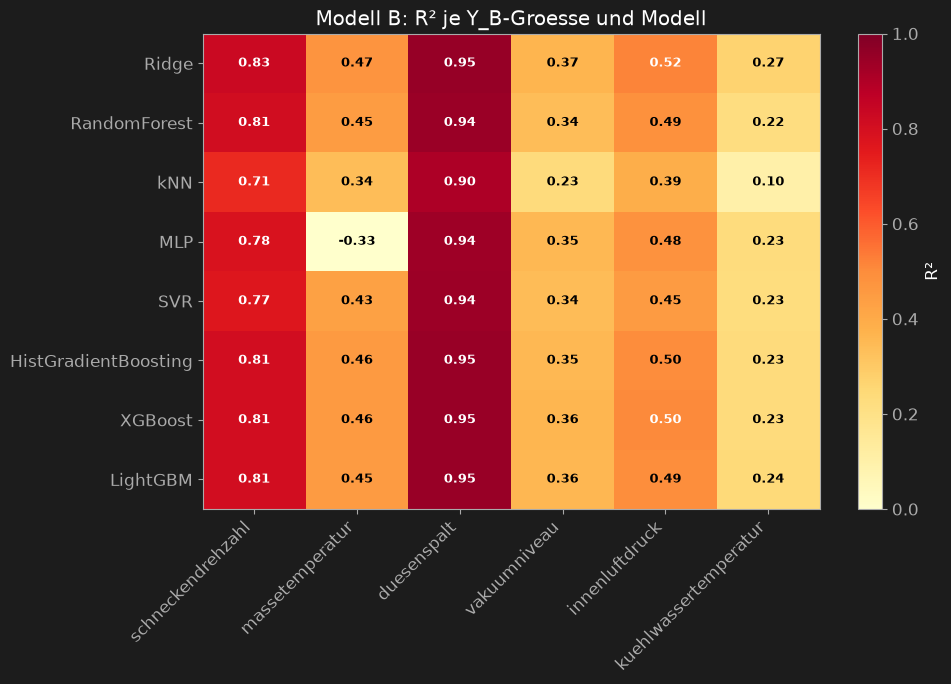

In [39]:
# =============================================================================
# Zelle 09b – Grafik: Heatmap R² je Y_B-Groesse x Modell
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 7))
matrix = aufschluesselung_df.values.astype(float)

im = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(aufschluesselung_df.columns)))
ax.set_xticklabels(aufschluesselung_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(aufschluesselung_df.index)))
ax.set_yticklabels(aufschluesselung_df.index)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        wert = matrix[i, j]
        textfarbe = "black" if wert < 0.5 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=9, fontweight="bold")

plt.colorbar(im, label="R²")
ax.set_title("Modell B: R² je Y_B-Groesse und Modell")
plt.tight_layout()
save_figure(fig, "../reports/figures/11_heatmap_r2_je_yb_model_b.png")
plt.show()

In [30]:
# =============================================================================
# Zelle 10 – Sane-Default-Kalibrierung: RandomForest (Overfitting) + MLP
# (Konvergenzproblem bei Massetemperatur)
# =============================================================================
# Begruendete Einzelkorrekturen (kein systematisches Tuning - das folgt
# in Notebook 12), analog zum Modell-A-Vorgehen (Notebook 05).
# RandomForest: Gap=0.235 (staerkstes Overfitting aller 8 Modelle) ->
#   Baumtiefe/Blattgroesse begrenzen, analog Modell A.
# MLP: negatives R2 bei Massetemperatur -> Konvergenz-Hinweis, hoehere
#   max_iter und angepasste Lernrate als erste, begruendete Korrektur.
# =============================================================================

MODELLE_B["RandomForest"]["modell"] = RandomForestRegressor(
    n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=SEED
)
MODELLE_B["MLP"]["modell"] = MLPRegressor(
    hidden_layer_sizes=(50,), max_iter=2000, early_stopping=True,
    learning_rate_init=0.005, n_iter_no_change=20, random_state=SEED
)

print("RandomForest kalibriert: max_depth 8->6, min_samples_leaf 3->5")
print("MLP kalibriert: max_iter 1000->2000, learning_rate_init=0.005 (neu), n_iter_no_change 10->20")

RandomForest kalibriert: max_depth 8->6, min_samples_leaf 3->5
MLP kalibriert: max_iter 1000->2000, learning_rate_init=0.005 (neu), n_iter_no_change 10->20


In [32]:
# =============================================================================
# Zelle 11 – Gezielter Nachtest: RandomForest + MLP nach Kalibrierung
# =============================================================================
from sklearn.base import clone

nachtest_ergebnisse = []

for modell_name in ["RandomForest", "MLP"]:
    for struktur in ["multioutput", "einzeln"]:
        eintrag = {"modell": modell_name, "struktur": struktur, "feature_set": "original"}
        fold_metriken_je_y = {y: [] for y in Y_B_MERKMALE}
        fold_metriken_train_je_y = {y: [] for y in Y_B_MERKMALE}
        fold_fit_zeiten = []

        for tr_idx, val_idx in fold_splits_idx:
            prep = baue_preprocessing_pipeline_b("original")
            X_tr = prep.fit_transform(df_b.loc[tr_idx])
            X_val = prep.transform(df_b.loc[val_idx])
            y_tr = df_b.loc[tr_idx, Y_B_MERKMALE]
            y_val = df_b.loc[val_idx, Y_B_MERKMALE]

            t0 = time.time()
            if struktur == "multioutput":
                modell = clone(MODELLE_B[modell_name]["modell"])
                modell.fit(X_tr, y_tr)
                y_pred_val = pd.DataFrame(modell.predict(X_val), columns=Y_B_MERKMALE, index=val_idx)
                y_pred_train = pd.DataFrame(modell.predict(X_tr), columns=Y_B_MERKMALE, index=tr_idx)
            else:
                y_pred_val = pd.DataFrame(index=val_idx, columns=Y_B_MERKMALE, dtype=float)
                y_pred_train = pd.DataFrame(index=tr_idx, columns=Y_B_MERKMALE, dtype=float)
                for y_col in Y_B_MERKMALE:
                    modell_einzeln = clone(MODELLE_B[modell_name]["modell"])
                    modell_einzeln.fit(X_tr, y_tr[y_col])
                    y_pred_val[y_col] = modell_einzeln.predict(X_val)
                    y_pred_train[y_col] = modell_einzeln.predict(X_tr)
            fold_fit_zeiten.append(time.time() - t0)

            for y_col in Y_B_MERKMALE:
                m_val = berechne_metriken_b(y_val[y_col], y_pred_val[y_col], y_std_je_merkmal[y_col])
                m_train = berechne_metriken_b(y_tr[y_col], y_pred_train[y_col], y_std_je_merkmal[y_col])
                fold_metriken_je_y[y_col].append(m_val)
                fold_metriken_train_je_y[y_col].append(m_train)

        for y_col in Y_B_MERKMALE:
            werte_val = [fm["r2"] for fm in fold_metriken_je_y[y_col]]
            werte_train = [fm["r2"] for fm in fold_metriken_train_je_y[y_col]]
            eintrag[f"{y_col}_r2_mean"] = round(np.mean(werte_val), 3)
            eintrag[f"{y_col}_r2_gap"] = round(np.mean(werte_train) - np.mean(werte_val), 3)

        eintrag["r2_durchschnitt"] = round(np.mean([eintrag[f"{y}_r2_mean"] for y in Y_B_MERKMALE]), 4)
        eintrag["gap_durchschnitt"] = round(np.mean([eintrag[f"{y}_r2_gap"] for y in Y_B_MERKMALE]), 4)
        eintrag["fit_zeit_sek"] = round(np.mean(fold_fit_zeiten), 4)

        nachtest_ergebnisse.append(eintrag)
        print(f"{modell_name:15s} {struktur:11s} -> R2={eintrag['r2_durchschnitt']:.4f}, Gap={eintrag['gap_durchschnitt']:.4f}, Zeit={eintrag['fit_zeit_sek']:.3f}s")

nachtest_df = pd.DataFrame(nachtest_ergebnisse)
nachtest_df.to_csv("../reports/tables/11_sane_default_nachtest.csv", index=False)

RandomForest    multioutput -> R2=0.5150, Gap=0.0803, Zeit=0.546s
RandomForest    einzeln     -> R2=0.5443, Gap=0.1388, Zeit=2.993s
MLP             multioutput -> R2=0.5278, Gap=0.0285, Zeit=1.208s
MLP             einzeln     -> R2=0.5305, Gap=0.0558, Zeit=4.222s


In [33]:
# =============================================================================
# Zelle 12 – Ablationsschleife Iteration 2 (RandomForest/MLP kalibriert)
# =============================================================================
# Identisch zu Zelle 05, aber mit den in Zelle 10 kalibrierten RandomForest/
# MLP-Einstellungen. Neue Ergebnisdatei (v2), alte bleibt als Vergleich
# erhalten.
# =============================================================================
OUTPUT_CSV_B_V2 = "../reports/tables/11_ablation_results_model_b_v2.csv"

ergebnisse_b_v2 = []
start_gesamt = time.time()

for kombi_idx, (modell_name, struktur, fs_name) in enumerate(kombinationen):
    eintrag = {"modell": modell_name, "struktur": struktur, "feature_set": fs_name, "status": "ok"}
    fold_metriken_je_y = {y: [] for y in Y_B_MERKMALE}
    fold_metriken_train_je_y = {y: [] for y in Y_B_MERKMALE}
    fold_fit_zeiten, fold_predict_zeiten = [], []

    try:
        for tr_idx, val_idx in fold_splits_idx:
            prep = baue_preprocessing_pipeline_b(fs_name)
            X_tr = prep.fit_transform(df_b.loc[tr_idx])
            X_val = prep.transform(df_b.loc[val_idx])
            y_tr = df_b.loc[tr_idx, Y_B_MERKMALE]
            y_val = df_b.loc[val_idx, Y_B_MERKMALE]

            t0 = time.time()
            if struktur == "multioutput":
                modell = clone(MODELLE_B[modell_name]["modell"])
                modell.fit(X_tr, y_tr)
                fit_zeit = time.time() - t0
                t1 = time.time()
                y_pred_val = pd.DataFrame(modell.predict(X_val), columns=Y_B_MERKMALE, index=val_idx)
                y_pred_train = pd.DataFrame(modell.predict(X_tr), columns=Y_B_MERKMALE, index=tr_idx)
                predict_zeit = time.time() - t1
            else:
                y_pred_val = pd.DataFrame(index=val_idx, columns=Y_B_MERKMALE, dtype=float)
                y_pred_train = pd.DataFrame(index=tr_idx, columns=Y_B_MERKMALE, dtype=float)
                predict_zeit_summe = 0
                for y_col in Y_B_MERKMALE:
                    modell_einzeln = clone(MODELLE_B[modell_name]["modell"])
                    modell_einzeln.fit(X_tr, y_tr[y_col])
                    t1 = time.time()
                    y_pred_val[y_col] = modell_einzeln.predict(X_val)
                    y_pred_train[y_col] = modell_einzeln.predict(X_tr)
                    predict_zeit_summe += time.time() - t1
                fit_zeit = time.time() - t0 - predict_zeit_summe
                predict_zeit = predict_zeit_summe

            fold_fit_zeiten.append(fit_zeit)
            fold_predict_zeiten.append(predict_zeit)

            for y_col in Y_B_MERKMALE:
                m_val = berechne_metriken_b(y_val[y_col], y_pred_val[y_col], y_std_je_merkmal[y_col])
                m_train = berechne_metriken_b(y_tr[y_col], y_pred_train[y_col], y_std_je_merkmal[y_col])
                fold_metriken_je_y[y_col].append(m_val)
                fold_metriken_train_je_y[y_col].append(m_train)

        for y_col in Y_B_MERKMALE:
            for metrik_key in ["mae", "rmse", "r2", "median_ae", "rmse_normiert", "mae_normiert"]:
                werte_val = [fm[metrik_key] for fm in fold_metriken_je_y[y_col]]
                werte_train = [fm[metrik_key] for fm in fold_metriken_train_je_y[y_col]]
                eintrag[f"{y_col}_{metrik_key}_mean"] = np.nanmean(werte_val)
                eintrag[f"{y_col}_{metrik_key}_std"] = np.nanstd(werte_val)
                eintrag[f"{y_col}_{metrik_key}_gap"] = np.nanmean(werte_train) - np.nanmean(werte_val)

        eintrag["fit_zeit_sekunden_mean"] = np.mean(fold_fit_zeiten)
        eintrag["predict_zeit_sekunden_mean"] = np.mean(fold_predict_zeiten)
        eintrag["r2_durchschnitt_alle_y"] = np.mean([eintrag[f"{y}_r2_mean"] for y in Y_B_MERKMALE])

    except Exception as e:
        eintrag["status"] = "fehlgeschlagen"
        eintrag["fehler"] = f"{type(e).__name__}: {str(e)[:300]}"

    ergebnisse_b_v2.append(eintrag)
    try:
        pd.DataFrame(ergebnisse_b_v2).to_csv(OUTPUT_CSV_B_V2, index=False)
        speicher_status = "gespeichert"
    except Exception as speicher_fehler:
        speicher_status = f"SPEICHERN FEHLGESCHLAGEN: {speicher_fehler}"
    print(f"[{kombi_idx+1}/{len(kombinationen)}] {modell_name:22s} {struktur:11s} {fs_name:16s} -> {eintrag['status']} ({speicher_status})")

print(f"\nGesamtzeit: {time.time()-start_gesamt:.1f}s")
ergebnisse_b_v2_df = pd.DataFrame(ergebnisse_b_v2)
print(f"Erfolgreich: {(ergebnisse_b_v2_df['status']=='ok').sum()} / {len(ergebnisse_b_v2_df)}")

# --- Finale Sicherung, unabhaengig vom Zwischenspeicher-Status ---
pd.DataFrame(ergebnisse_b_v2).to_csv(OUTPUT_CSV_B_V2, index=False)
print(f"Finale Sicherung abgeschlossen: {OUTPUT_CSV_B_V2}")

[1/48] Ridge                  multioutput original         -> ok (gespeichert)
[2/48] Ridge                  multioutput nur_dn           -> ok (gespeichert)
[3/48] Ridge                  multioutput nur_wandstaerke  -> ok (gespeichert)
[4/48] Ridge                  multioutput residualisiert   -> ok (gespeichert)
[5/48] Ridge                  einzeln     original         -> ok (gespeichert)
[6/48] Ridge                  einzeln     nur_dn           -> ok (gespeichert)
[7/48] Ridge                  einzeln     nur_wandstaerke  -> ok (gespeichert)
[8/48] Ridge                  einzeln     residualisiert   -> ok (gespeichert)
[9/48] RandomForest           multioutput original         -> ok (gespeichert)
[10/48] RandomForest           multioutput nur_dn           -> ok (gespeichert)
[11/48] RandomForest           multioutput nur_wandstaerke  -> ok (gespeichert)
[12/48] RandomForest           multioutput residualisiert   -> ok (gespeichert)
[13/48] RandomForest           einzeln     origin

In [40]:
# =============================================================================
# Zelle 13 – Zwischentabellen fuer v2-Grafiken (nach Sane-Default-Kalibrierung)
# =============================================================================
# Analog zu fs_vergleich_df (Zelle 07) und gesamt_df (Zelle 08), aber auf
# Basis der kalibrierten Ergebnisse (ergebnisse_b_v2_df).
# =============================================================================

# --- fs_vergleich_df_v2 (analog Zelle 07) ---
feature_set_vergleich_v2 = []
for modell_name, struktur in beste_struktur_je_modell.items():
    for fs_name in FEATURE_SETS_B:
        zeile = ergebnisse_b_v2_df[(ergebnisse_b_v2_df["modell"]==modell_name) & (ergebnisse_b_v2_df["struktur"]==struktur) & (ergebnisse_b_v2_df["feature_set"]==fs_name)]
        if len(zeile) == 0:
            continue
        feature_set_vergleich_v2.append({"modell": modell_name, "feature_set": fs_name, "r2_durchschnitt": round(zeile.iloc[0]["r2_durchschnitt_alle_y"], 4)})
fs_vergleich_df_v2 = pd.DataFrame(feature_set_vergleich_v2)

# --- gesamt_df_v2 (analog Zelle 08) ---
y_cols_gap = [f"{y}_r2_gap" for y in Y_B_MERKMALE]
ergebnisse_b_v2_df["gap_durchschnitt_alle_y"] = ergebnisse_b_v2_df[y_cols_gap].mean(axis=1)

gesamtvergleich_v2 = []
for modell_name, struktur in beste_struktur_je_modell.items():
    zeile = ergebnisse_b_v2_df[(ergebnisse_b_v2_df["modell"]==modell_name) & (ergebnisse_b_v2_df["struktur"]==struktur) & (ergebnisse_b_v2_df["feature_set"]=="original")]
    if len(zeile) == 0:
        continue
    row = zeile.iloc[0]
    gesamtvergleich_v2.append({
        "modell": modell_name, "struktur": struktur,
        "r2_durchschnitt": round(row["r2_durchschnitt_alle_y"], 4),
        "r2_gap_durchschnitt": round(row["gap_durchschnitt_alle_y"], 4),
        "fit_zeit_sek": round(row["fit_zeit_sekunden_mean"], 4),
    })
gesamt_df_v2 = pd.DataFrame(gesamtvergleich_v2).sort_values("r2_durchschnitt", ascending=False)

# --- aufschluesselung_df_v2 (analog Zelle 09) ---
aufschluesselung_v2 = []
for modell_name, struktur in beste_struktur_je_modell.items():
    zeile = ergebnisse_b_v2_df[(ergebnisse_b_v2_df["modell"]==modell_name) & (ergebnisse_b_v2_df["struktur"]==struktur) & (ergebnisse_b_v2_df["feature_set"]=="original")]
    if len(zeile) == 0:
        continue
    row = zeile.iloc[0]
    eintrag = {"modell": modell_name}
    for y_col in Y_B_MERKMALE:
        eintrag[y_col] = round(row[f"{y_col}_r2_mean"], 3)
    aufschluesselung_v2.append(eintrag)
aufschluesselung_df_v2 = pd.DataFrame(aufschluesselung_v2).set_index("modell")

print("=== gesamt_df_v2 ===")
print(gesamt_df_v2.to_string(index=False))
print("\n=== aufschluesselung_df_v2 ===")
print(aufschluesselung_df_v2.to_string())

fs_vergleich_df_v2.to_csv("../reports/tables/11_feature_set_vergleich_model_b_v2.csv", index=False)
gesamt_df_v2.to_csv("../reports/tables/11_gesamtvergleich_model_b_v2.csv", index=False)
aufschluesselung_df_v2.to_csv("../reports/tables/11_r2_je_y_b_groesse_v2.csv")

=== gesamt_df_v2 ===
              modell    struktur  r2_durchschnitt  r2_gap_durchschnitt  fit_zeit_sek
               Ridge multioutput           0.5674               0.0063        0.0032
             XGBoost     einzeln           0.5515               0.0930        0.1345
            LightGBM     einzeln           0.5493               0.0835        0.0918
HistGradientBoosting     einzeln           0.5490               0.0919        0.4149
        RandomForest     einzeln           0.5443               0.1390        3.0385
                 MLP multioutput           0.5276               0.0284        1.4951
                 SVR     einzeln           0.5261               0.0396        0.2476
                 kNN multioutput           0.4461               0.1860        0.0027

=== aufschluesselung_df_v2 ===
                      schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
modell                                                     

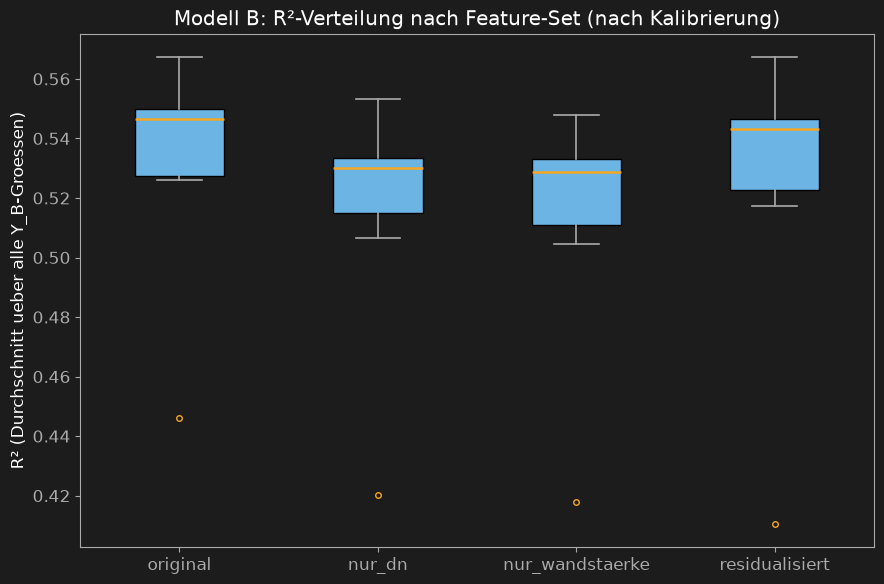

In [41]:
# =============================================================================
# Zelle 14 – Grafik: Boxplot R2-Verteilung ueber Feature-Sets (nach Kalibrierung)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))
daten_je_fs = [fs_vergleich_df_v2[fs_vergleich_df_v2["feature_set"]==fs]["r2_durchschnitt"].values for fs in FEATURE_SETS_B]
bp = ax.boxplot(daten_je_fs, tick_labels=list(FEATURE_SETS_B.keys()), patch_artist=True, **BOXPLOT_STYLE)
for box in bp["boxes"]:
    box.set_facecolor(COLOR_BLUE)
ax.set_ylabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_title("Modell B: R²-Verteilung nach Feature-Set (nach Kalibrierung)")
plt.tight_layout()
save_figure(fig, "../reports/figures/14_boxplot_feature_sets_model_b_kalibriert.png")
plt.show()

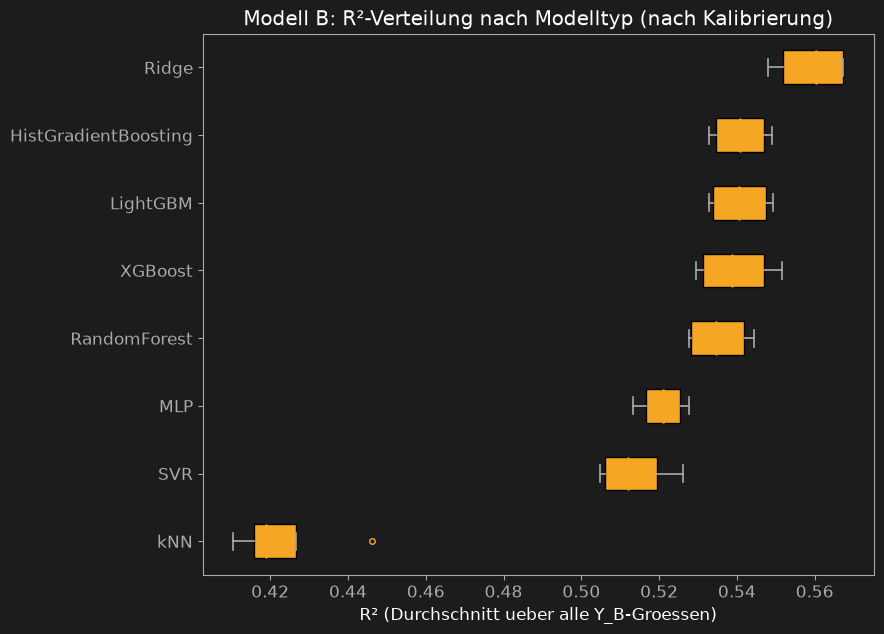

In [42]:
# =============================================================================
# Zelle 15 – Grafik: Boxplot R2-Verteilung ueber Modelltypen (nach Kalibrierung)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6.5))
modelle_sortiert_v2 = fs_vergleich_df_v2.groupby("modell")["r2_durchschnitt"].median().sort_values(ascending=True).index.tolist()
daten_je_modell = [fs_vergleich_df_v2[fs_vergleich_df_v2["modell"]==m]["r2_durchschnitt"].values for m in modelle_sortiert_v2]
bp = ax.boxplot(daten_je_modell, tick_labels=modelle_sortiert_v2, patch_artist=True, vert=False, **BOXPLOT_STYLE)
for box in bp["boxes"]:
    box.set_facecolor(COLOR_GOLD)
ax.set_xlabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_title("Modell B: R²-Verteilung nach Modelltyp (nach Kalibrierung)")
plt.tight_layout()
save_figure(fig, "../reports/figures/15_boxplot_modelltypen_model_b_kalibriert.png")
plt.show()

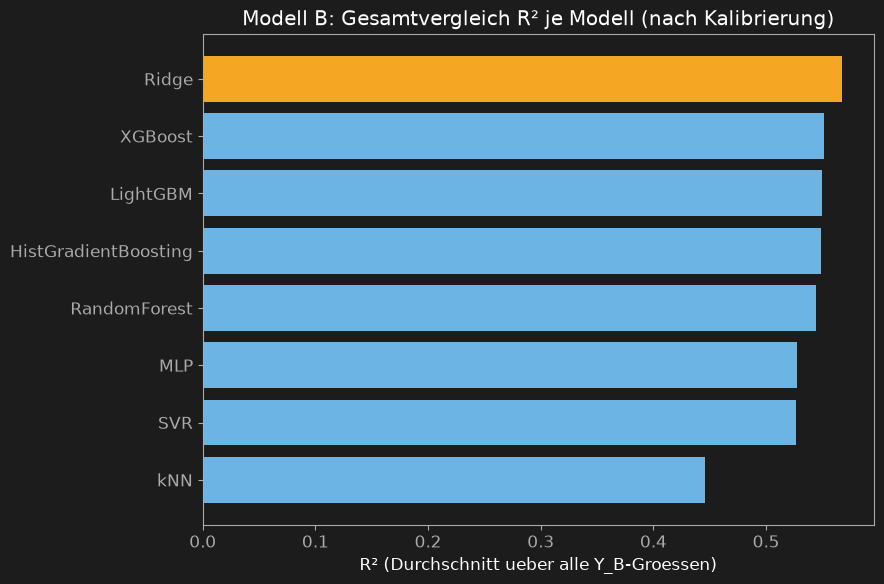

In [43]:
# =============================================================================
# Zelle 16 – Grafik: R² je Modell (nach Kalibrierung)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))
gesamt_sortiert_v2 = gesamt_df_v2.sort_values("r2_durchschnitt", ascending=True)
farben = [COLOR_GOLD if m == gesamt_sortiert_v2.iloc[-1]["modell"] else COLOR_BLUE for m in gesamt_sortiert_v2["modell"]]
ax.barh(gesamt_sortiert_v2["modell"], gesamt_sortiert_v2["r2_durchschnitt"], color=farben)
ax.set_xlabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_title("Modell B: Gesamtvergleich R² je Modell (nach Kalibrierung)")
plt.tight_layout()
save_figure(fig, "../reports/figures/16_r2_je_modell_model_b_kalibriert.png")
plt.show()

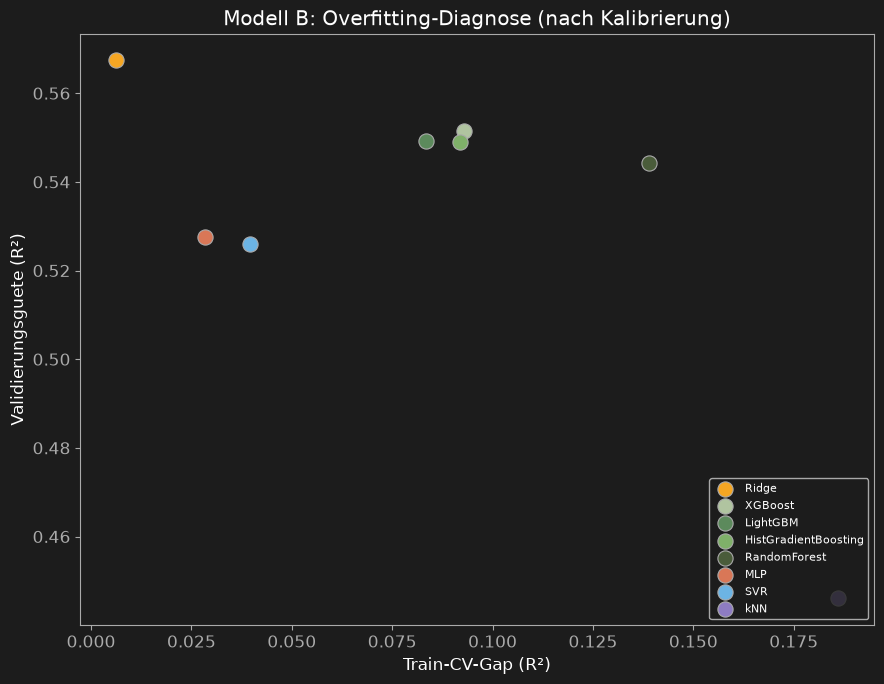

In [44]:
# =============================================================================
# Zelle 17 – Grafik: Train-CV-Gap vs. R² (nach Kalibrierung)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 7))
for _, row in gesamt_df_v2.iterrows():
    ax.scatter(row["r2_gap_durchschnitt"], row["r2_durchschnitt"], color=modell_farben_b.get(row["modell"], COLOR_TEXT_MUTED),
               s=120, edgecolors=COLOR_TEXT_MUTED, linewidths=0.8, label=row["modell"])
ax.set_xlabel("Train-CV-Gap (R²)")
ax.set_ylabel("Validierungsguete (R²)")
ax.set_title("Modell B: Overfitting-Diagnose (nach Kalibrierung)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
save_figure(fig, "../reports/figures/17_overfitting_diagnose_model_b_kalibriert.png")
plt.show()

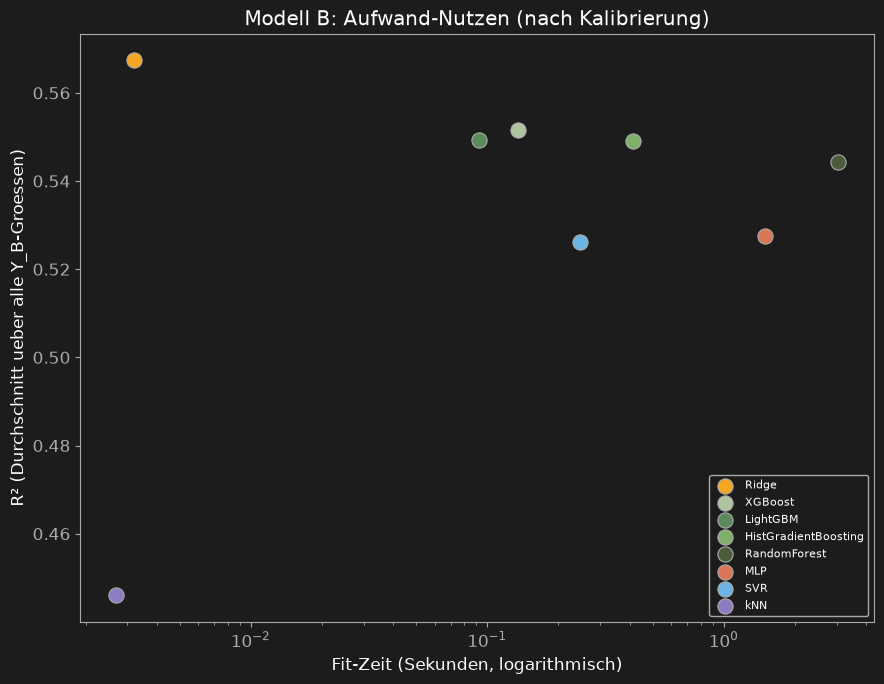

In [45]:
# =============================================================================
# Zelle 18 – Grafik: Fit-Zeit vs. R² (nach Kalibrierung)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 7))
for _, row in gesamt_df_v2.iterrows():
    ax.scatter(row["fit_zeit_sek"], row["r2_durchschnitt"], color=modell_farben_b.get(row["modell"], COLOR_TEXT_MUTED),
               s=120, edgecolors=COLOR_TEXT_MUTED, linewidths=0.8, label=row["modell"])
ax.set_xlabel("Fit-Zeit (Sekunden, logarithmisch)")
ax.set_ylabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_xscale("log")
ax.set_title("Modell B: Aufwand-Nutzen (nach Kalibrierung)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
save_figure(fig, "../reports/figures/18_aufwand_nutzen_model_b_kalibriert.png")
plt.show()

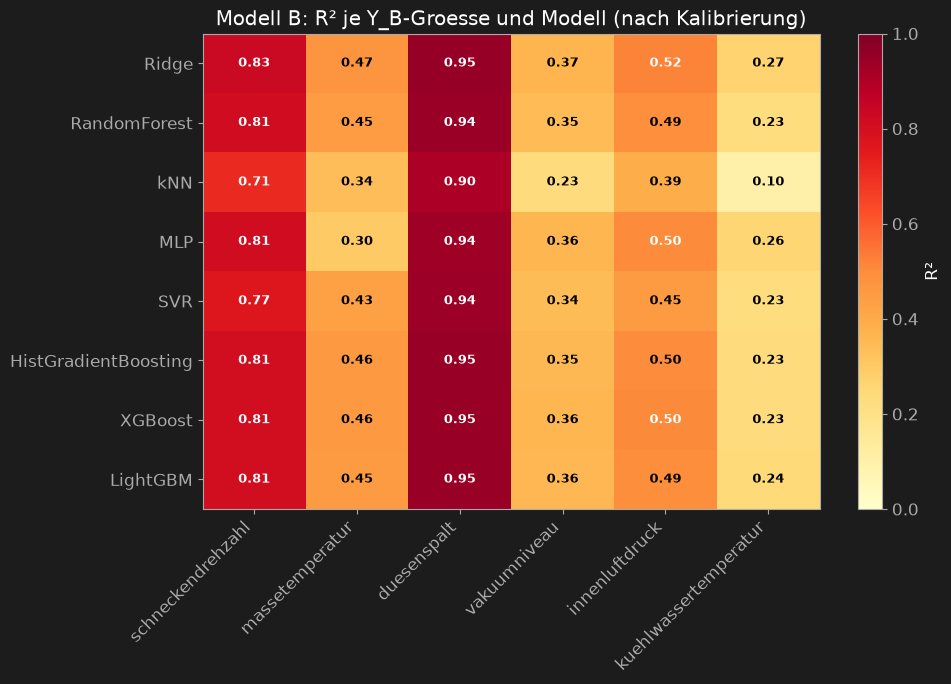

In [46]:
# =============================================================================
# Zelle 19 – Grafik: Heatmap R² je Y_B-Groesse x Modell (nach Kalibrierung)
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 7))
matrix_v2 = aufschluesselung_df_v2.values.astype(float)
im = ax.imshow(matrix_v2, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(aufschluesselung_df_v2.columns)))
ax.set_xticklabels(aufschluesselung_df_v2.columns, rotation=45, ha="right")
ax.set_yticks(range(len(aufschluesselung_df_v2.index)))
ax.set_yticklabels(aufschluesselung_df_v2.index)
for i in range(matrix_v2.shape[0]):
    for j in range(matrix_v2.shape[1]):
        wert = matrix_v2[i, j]
        textfarbe = "black" if wert < 0.5 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=9, fontweight="bold")
plt.colorbar(im, label="R²")
ax.set_title("Modell B: R² je Y_B-Groesse und Modell (nach Kalibrierung)")
plt.tight_layout()
save_figure(fig, "../reports/figures/19_heatmap_r2_je_yb_model_b_kalibriert.png")
plt.show()

              modell  r2_durchschnitt    r2_std
               Ridge           0.5674  0.028507
             XGBoost           0.5515  0.028594
            LightGBM           0.5493  0.029355
HistGradientBoosting           0.5490   0.02987
        RandomForest           0.5443  0.031701
                 MLP           0.5276  0.029636
                 SVR           0.5261  0.024076
                 kNN           0.4461  0.031868


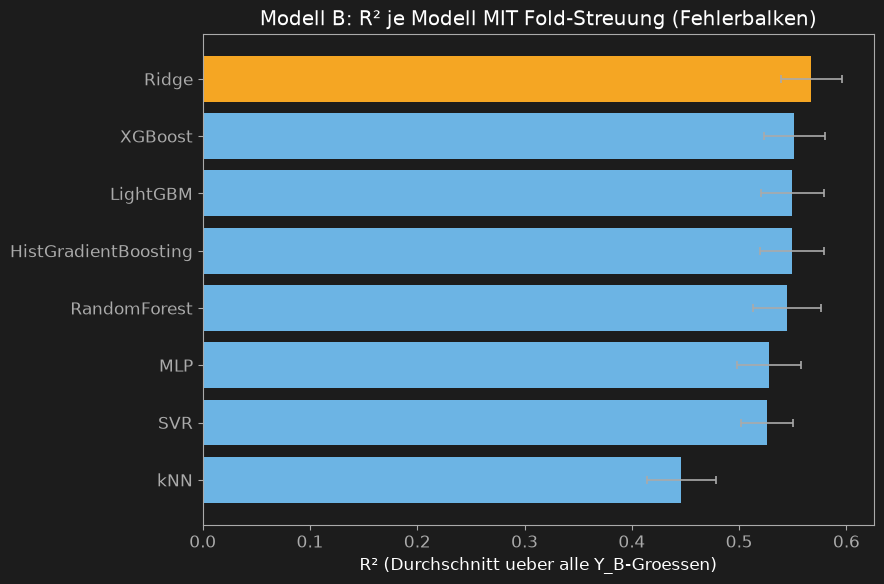

In [47]:
# =============================================================================
# Zelle 20 – Fold-Std je Modell + Balkengrafik MIT Fehlerbalken
# =============================================================================
# Fehlt bisher komplett - notwendig, um zu pruefen, ob sich die R2-Werte
# der Modelle tatsaechlich signifikant unterscheiden, oder ob sie sich
# innerhalb der Fold-zu-Fold-Streuung ueberlappen (analog Modell A Grafik 1).
# =============================================================================

gesamt_df_v2["r2_std"] = None
for idx, row in gesamt_df_v2.iterrows():
    zeile = ergebnisse_b_v2_df[(ergebnisse_b_v2_df["modell"]==row["modell"]) & (ergebnisse_b_v2_df["struktur"]==row["struktur"]) & (ergebnisse_b_v2_df["feature_set"]=="original")]
    # Std ueber die 6 Y_B r2_std-Werte gemittelt (durchschnittliche Fold-Streuung)
    std_werte = [zeile.iloc[0][f"{y}_r2_std"] for y in Y_B_MERKMALE]
    gesamt_df_v2.loc[idx, "r2_std"] = np.mean(std_werte)

print(gesamt_df_v2[["modell","r2_durchschnitt","r2_std"]].sort_values("r2_durchschnitt", ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
gesamt_sortiert_std = gesamt_df_v2.sort_values("r2_durchschnitt", ascending=True)
farben = [COLOR_GOLD if m == gesamt_sortiert_std.iloc[-1]["modell"] else COLOR_BLUE for m in gesamt_sortiert_std["modell"]]

ax.barh(gesamt_sortiert_std["modell"], gesamt_sortiert_std["r2_durchschnitt"],
        xerr=gesamt_sortiert_std["r2_std"].astype(float), color=farben,
        error_kw=dict(ecolor=COLOR_TEXT_MUTED, capsize=3, capthick=1.2, elinewidth=1.2))
ax.set_xlabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_title("Modell B: R² je Modell MIT Fold-Streuung (Fehlerbalken)")
plt.tight_layout()
save_figure(fig, "../reports/figures/20_r2_je_modell_mit_fehlerbalken.png")
plt.show()

gesamt_df_v2.to_csv("../reports/tables/20_gesamtvergleich_mit_std.csv", index=False)

## Notebook 11 – Abschluss: Modelltraining Modell B (Ablationsstudie)

### Durchgefuehrte Schritte
| Zelle | Inhalt | Status |
|---|---|---|
| 01-04 | Setup, Split, Modell-Registry (8 Typen), Metrik-Funktion | Erledigt |
| 05 | Ablationsschleife Iteration 1 (48 Kombinationen, unkalibriert) | Erledigt |
| 06-09 | Frage 1 (Multi-Output vs. Einzeln), Frage 2 (Feature-Set), Gesamtvergleich, Y_B-Aufschluesselung | Erledigt |
| 10-12 | Sane-Default-Kalibrierung (RandomForest, MLP), Nachtest, Ablationsschleife Iteration 2 | Erledigt |
| 13-19 | Zwischentabellen v2, 12 Grafiken (6 vor / 6 nach Kalibrierung) | Erledigt |
| 20 | Fold-Streuung/Fehlerbalken - KRITISCHE KORREKTUR | Erledigt |

### Zentrale, datengetriebene Antworten
1. **Multi-Output vs. Einzelmodelle:** modellabhaengig - Ridge/kNN identisch
   (kein Genauigkeitsunterschied, Multi-Output schneller), RandomForest
   leicht besser einzeln, MLP klar besser multioutput (Interaktionen
   zwischen den 6 Y_B-Groessen werden genutzt)
2. **Feature-Set:** "original" (DN+Wandstaerke beide behalten) gewinnt
   konsistent bei 8/8 Modellen - urspruengliche Multikollinearitaets-
   Sorge (r=0.957) empirisch NICHT als Problem bestaetigt,
   Residualisierung schadete durchweg

### Sane-Default-Kalibrierung (punktuell, RandomForest + MLP)
RandomForest: Gap 0.235->0.139 (einzeln) reduziert durch max_depth 8->6,
min_samples_leaf 3->5. MLP: R² 0.37-0.41->0.53 durch Konvergenz-Fix
(hoehere max_iter, angepasste Lernrate) - Massetemperatur-Ausreisser
(R²=-0.327) behoben (jetzt 0.300).

### KRITISCHE KORREKTUR (Nutzer-Einwand, wichtige Lehre):
Erste Champion-Aussage ("Ridge gewinnt klar") war VORSCHNELL - Fold-
Streuung (Std) wurde zunaechst nicht mit betrachtet. Nach Ergaenzung
(Zelle 20): die Top-5-Modelle (Ridge 0.567±0.029, XGBoost 0.552±0.029,
LightGBM 0.549±0.029, HistGB 0.549±0.030, RandomForest 0.544±0.032)
UEBERLAPPEN SICH statistisch - kein robust nachweisbarer Genauigkeits-
unterschied zwischen ihnen. Nur kNN (0.446±0.032) hebt sich klar
negativ ab. KORRIGIERTE Champion-Begruendung: Ridge nicht wegen hoechster
Genauigkeit (nicht robust belegbar), sondern wegen nachweisbar
geringstem Overfitting-Gap (0.006 vs. 0.08-0.14, NICHT ueberlappend)
und massiv geringerem Rechenaufwand.

### Zweite kritische Selbstpruefung (Nutzer-Einwand): Hyperparameter ungeprueft
Fast alle 8 Modelle nutzten Hyperparameter, die entweder 1:1 von Modell A
(n=560) uebernommen wurden (nicht an Modell B's n=1600 angepasst) oder
sklearn-Defaults ohne jede Pruefung waren (Ridge alpha, kNN n_neighbors,
SVR C/gamma, MLP hidden_layer_sizes). NUR RandomForest/MLP wurden bisher
punktuell korrigiert. Entscheidung: systematisches Hyperparameter-Tuning
fuer ALLE 8 Modelle notwendig (Notebook 12), bevor eine belastbare
finale Champion-Entscheidung getroffen werden kann - bisherige
"Spitzengruppe"-Erkenntnis koennte sich durch korrektes Tuning veraendern.

### Bekannte Limitationen
- Feature-Set/Struktur-Frage nur mit Default-Hyperparametern beantwortet -
  moeglich, dass sich die Antworten nach Tuning aendern (zu pruefen)
- Kein "blinder" Bayes-Floor verfuegbar (siehe Notebook-09-Klaerung),
  aktuelles bestes R² ist die vorlaeufige Empirical-Upper-Bound-Schaetzung

### Naechster Schritt
Notebook 12: systematisches Hyperparameter-Tuning (Nested CV, 5x5 Folds)
fuer alle 8 Modelle, Feature-Set "original" fixiert - klaert, ob die
aktuelle Spitzengruppen-Erkenntnis nach fairer Kalibrierung Bestand hat.